In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [139]:
# Read the .csv file
path = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\experiments.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        df[column] = [np.array(eval(i)) for i in df[column].values]
        
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['train_S1_p']
Task

['domainbody' 'backward' 'known' 'full' 'domain']
Grounder

['complex' 'distmult' 'transe']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['no_reasoner' 'dcr' 'r2n' 'sbr' 'rnm']
Model_name



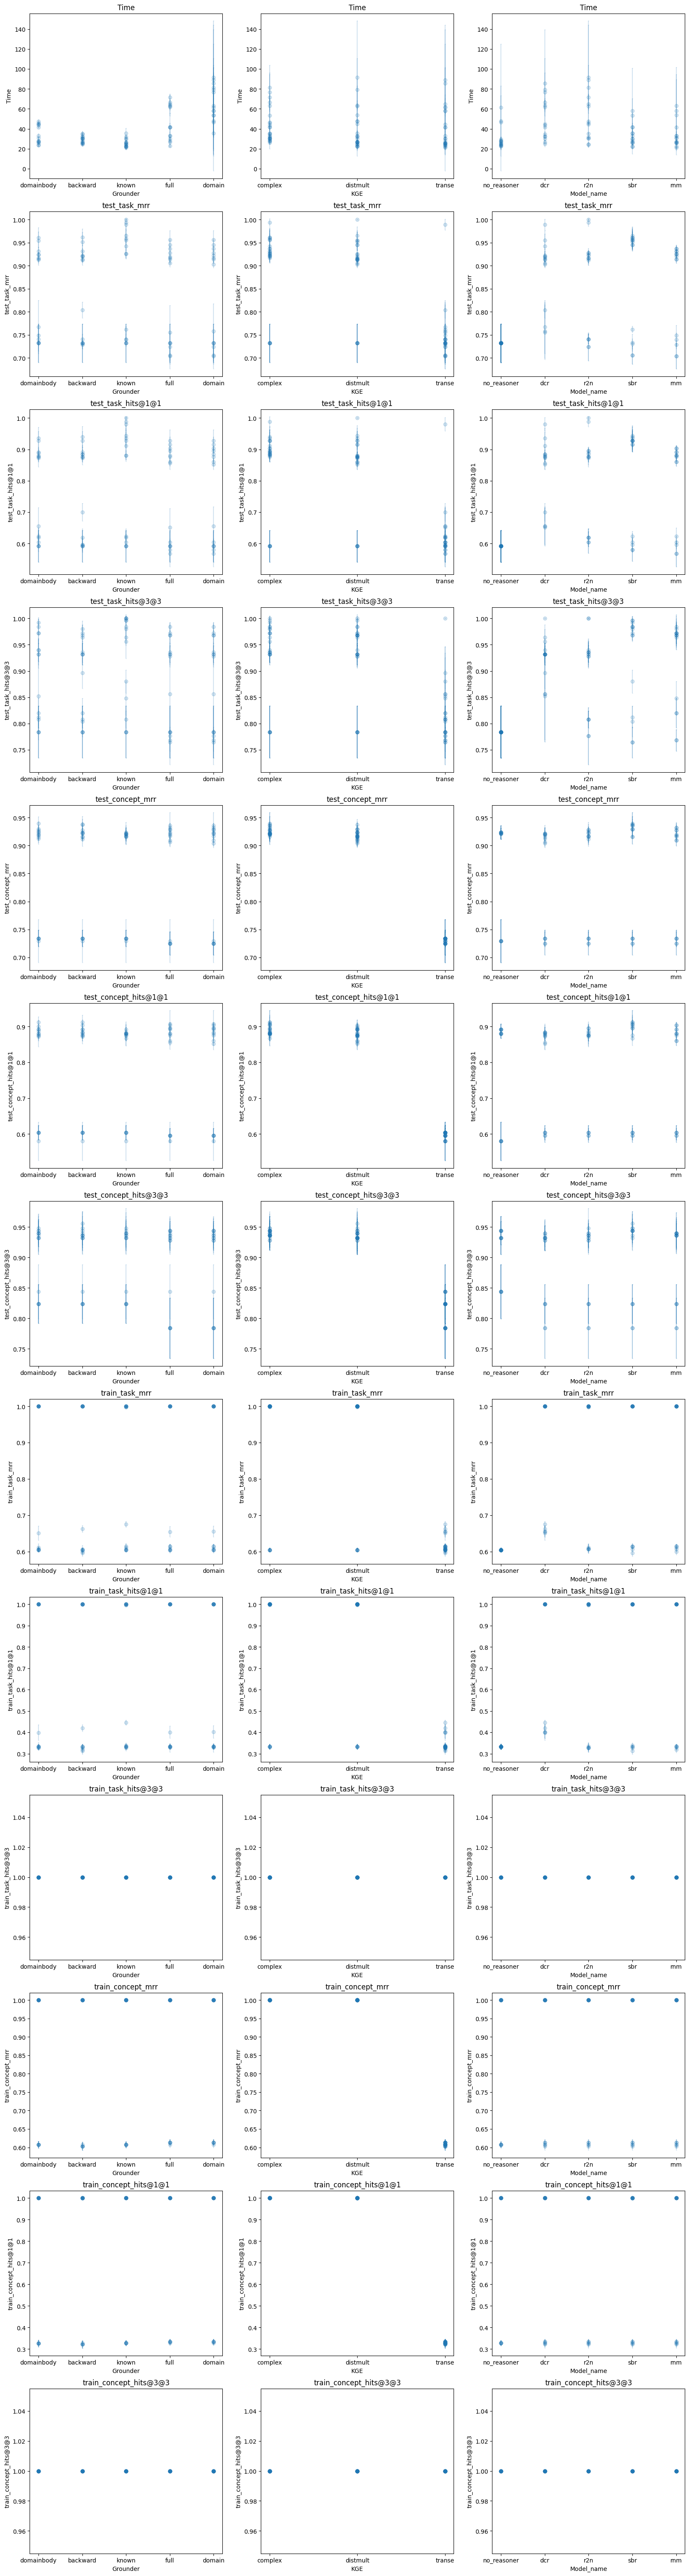

In [140]:
# df = df[df['Model_name'] != 'no_reasoner']
AX = ['Grounder','KGE', 'Model_name'] 
    # ['train_loss', 'train_concept_loss', 'train_task_loss']
    # ['train_concept_mrr', 'train_concept_hits@1@1', 'train_concept_hits@3@3','train_concept_hits@5@5', 'train_concept_hits@10@10']
    # ['train_task_mrr', 'train_task_hits@1@1', 'train_task_hits@3@3','train_task_hits@5@5', 'train_task_hits@10@10']

    # ['val_loss', 'val_concept_loss', 'val_task_loss']
    # ['val_concept_mrr', 'val_concept_hits@1@1', 'val_concept_hits@3@3','val_concept_hits@5@5', 'val_concept_hits@10@10']
    # ['val_task_mrr', 'val_task_hits@1@1', 'val_task_hits@3@3','val_task_hits@5@5', 'val_task_hits@10@10']

    # ['test_loss', 'test_concept_loss', 'test_task_loss']
    # ['test_concept_mrr', 'test_concept_hits@1@1', 'test_concept_hits@3@3','test_concept_hits@5@5', 'test_concept_hits@10@10']
    # ['test_task_mrr', 'test_task_hits@1@1', 'test_task_hits@3@3','test_task_hits@5@5', 'test_task_hits@10@10']

AY = ['Time','test_task_mrr', 'test_task_hits@1@1', 'test_task_hits@3@3', #'test_task_hits@5@5', 'test_task_hits@10@10',
    'test_concept_mrr', 'test_concept_hits@1@1', 'test_concept_hits@3@3', #'test_concept_hits@5@5', 'test_concept_hits@10@10',
    'train_task_mrr', 'train_task_hits@1@1', 'train_task_hits@3@3', #'train_task_hits@5@5', 'train_task_hits@10@10',
    'train_concept_mrr', 'train_concept_hits@1@1', 'train_concept_hits@3@3'] #'train_concept_hits@5@5', 'train_concept_hits@10@10']
 
nrows = len(AY)
ncols = len(AX)
fig, axs = plt.subplots(len(AY), len(AX),figsize=(20,len(AY)*6))
for i,ax in enumerate(AX):
    for j,ay in enumerate(AY):
        # print(i,j,ax,ay)
        axs[j,i].scatter(df[ax].values.tolist(),np.stack(df[[ay]].to_numpy().flatten(), axis=0)[:,0], alpha = 0.2)
        # do the plot including the std deviation
        axs[j,i].errorbar(df[ax].values.tolist(), np.stack(df[[ay]].to_numpy().flatten(), axis=0)[:,0], yerr=np.stack(df[[ay]].to_numpy().flatten(), axis=0)[:,1], linestyle='None',capsize=1,alpha = 0.2)
        axs[j,i].set_title(ay)
        axs[j,i].set_xticklabels 
        axs[j,i].set_xlabel(ax)
        axs[j,i].set_ylabel(ay) 
plt.show()



In [55]:
# Table 1: rows:grounder, cols:Model, values: mrr
results = df.loc[ (df['KGE'] == 'complex') & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
# take only the columns grounder, model, test_task_mrr, test_concept_mrr
results = results[['Grounder', 'Model_name', 'test_task_mrr']]#, 'test_concept_mrr']]
# put the model_name as colums
results = results.pivot(index='Grounder', columns='Model_name', values='test_task_mrr')
print(results.head())

# in the column no_reasoner, put the values of the column test_concept_mrr
substitute = df.loc[ (df['KGE'] == 'complex') & (df['Model_name'] == 'no_reasoner') & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][['Grounder','Model_name','test_concept_mrr']]
substitute = substitute.pivot(index='Grounder', columns='Model_name', values='test_concept_mrr')
print(substitute)

results['no_reasoner'] = substitute['no_reasoner']
results

Model_name               dcr       no_reasoner               r2n  \
Grounder                                                           
backward     [0.9206, 0.011]  [0.7321, 0.0418]  [0.9224, 0.0153]   
domain      [0.9221, 0.0144]  [0.7321, 0.0418]  [0.9281, 0.0044]   
domainbody   [0.917, 0.0112]  [0.7321, 0.0418]  [0.9247, 0.0097]   
full        [0.9199, 0.0116]  [0.7321, 0.0418]  [0.9281, 0.0044]   
known       [0.9424, 0.0272]  [0.7321, 0.0418]    [0.994, 0.008]   

Model_name               rnm               sbr  
Grounder                                        
backward    [0.9317, 0.0138]  [0.9617, 0.0184]  
domain       [0.937, 0.0068]  [0.9567, 0.0202]  
domainbody  [0.9317, 0.0092]  [0.9611, 0.0219]  
full         [0.937, 0.0068]  [0.9567, 0.0202]  
known       [0.9263, 0.0099]   [0.959, 0.0212]  
Model_name       no_reasoner
Grounder                    
backward    [0.9215, 0.0099]
domain      [0.9215, 0.0099]
domainbody  [0.9215, 0.0099]
full        [0.9215, 0.0099]
known 

Model_name,dcr,no_reasoner,r2n,rnm,sbr
Grounder,,,,,
backward,"[0.9206, 0.011]","[0.9215, 0.0099]","[0.9224, 0.0153]","[0.9317, 0.0138]","[0.9617, 0.0184]"
domain,"[0.9221, 0.0144]","[0.9215, 0.0099]","[0.9281, 0.0044]","[0.937, 0.0068]","[0.9567, 0.0202]"
domainbody,"[0.917, 0.0112]","[0.9215, 0.0099]","[0.9247, 0.0097]","[0.9317, 0.0092]","[0.9611, 0.0219]"
full,"[0.9199, 0.0116]","[0.9215, 0.0099]","[0.9281, 0.0044]","[0.937, 0.0068]","[0.9567, 0.0202]"
known,"[0.9424, 0.0272]","[0.9215, 0.0099]","[0.994, 0.008]","[0.9263, 0.0099]","[0.959, 0.0212]"


In [137]:
results['dcr'].values[0]

Grounder
backward       [0.9206, 0.011]
domain        [0.9221, 0.0144]
domainbody     [0.917, 0.0112]
full          [0.9199, 0.0116]
known         [0.9424, 0.0272]
Name: dcr, dtype: object

ValueError: setting an array element with a sequence.

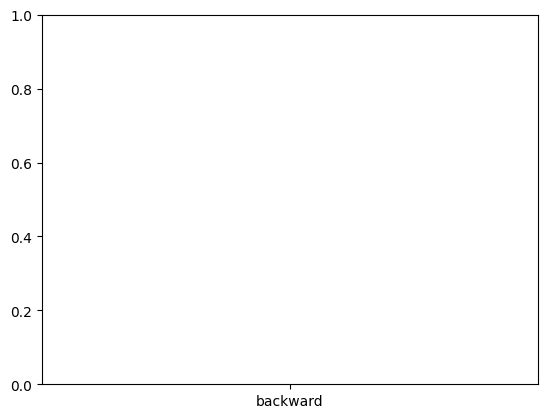

In [136]:
plt.plot(results['dcr'])

In [111]:
# number of cols of results
ncols = len(results.columns)
# number of rows of results
nrows = len(results.index)

# Convert the array to a NumPy array
array_np = np.array(results.to_numpy())

# Reshape and stack the arrays
stacked_array = np.stack(array_np.ravel()).reshape((nrows, ncols, 2))
# print(stacked_array)
# swap the first and second axis
stacked_array = stacked_array.swapaxes(0,1)
print(stacked_array[:,:,0])

[[0.9206 0.9221 0.917  0.9199 0.9424]
 [0.9215 0.9215 0.9215 0.9215 0.9215]
 [0.9224 0.9281 0.9247 0.9281 0.994 ]
 [0.9317 0.937  0.9317 0.937  0.9263]
 [0.9617 0.9567 0.9611 0.9567 0.959 ]]


In [129]:
# create an array with the names of the rows
rows = np.array(results.index)
# repeate it ncols times
rows = np.repeat(rows, ncols)
# reshape it to a column
rows = rows.reshape((nrows, ncols))
rows = rows.swapaxes(0,1)
print(rows)

[['backward' 'domain' 'domainbody' 'full' 'known']
 ['backward' 'domain' 'domainbody' 'full' 'known']
 ['backward' 'domain' 'domainbody' 'full' 'known']
 ['backward' 'domain' 'domainbody' 'full' 'known']
 ['backward' 'domain' 'domainbody' 'full' 'known']]


In [131]:
# create an array from range 0 to ncols, and repeat it nrows times
cols = np.tile(np.arange(ncols), nrows)
# reshape it to a column
cols = cols.reshape((ncols, nrows))
print(cols)

[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]


In [134]:
results.columns

Index(['dcr', 'no_reasoner', 'r2n', 'rnm', 'sbr'], dtype='object', name='Model_name')

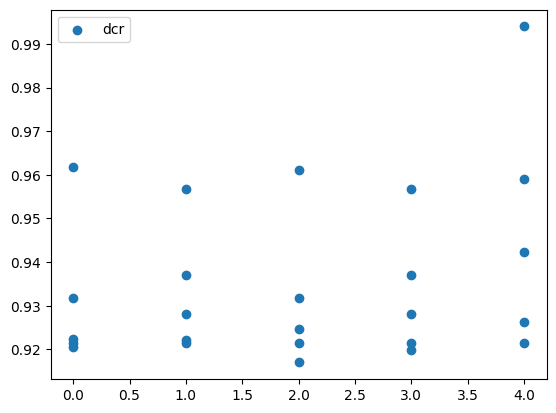

In [135]:
# do a scatter plot with the 5 series from the stacked array. The rows are the types of grounders
plt.scatter(cols,stacked_array[:,:,0])
# include the legend, each array is one model
plt.legend(results.columns)

In [87]:
#plot the table with grounder in the x axis and r2n in the y axis
ax = 'Grounder'
ay = 'r2n'
# print(i,j,ax,ay)
axs[j,i].scatter(results.values.tolist(),np.stack(results[[ay]].to_numpy().flatten(), axis=0)[:,0], alpha = 0.2)
# do the plot including the std deviation
# axs[j,i].errorbar(results[ax].values.tolist(), np.stack(results[[ay]].to_numpy().flatten(), axis=0)[:,0], yerr=np.stack(results[[ay]].to_numpy().flatten(), axis=0)[:,1], linestyle='None',capsize=1,alpha = 0.2)
# axs[j,i].set_title(ay)
# axs[j,i].set_xticklabels 
# axs[j,i].set_xlabel(ax)
# axs[j,i].set_ylabel(ay) 

ConversionError: Failed to convert value(s) to axis units: [[array([0.9206, 0.011 ]), array([0.9215, 0.0099]), array([0.9224, 0.0153]), array([0.9317, 0.0138]), array([0.9617, 0.0184])], [array([0.9221, 0.0144]), array([0.9215, 0.0099]), array([0.9281, 0.0044]), array([0.937 , 0.0068]), array([0.9567, 0.0202])], [array([0.917 , 0.0112]), array([0.9215, 0.0099]), array([0.9247, 0.0097]), array([0.9317, 0.0092]), array([0.9611, 0.0219])], [array([0.9199, 0.0116]), array([0.9215, 0.0099]), array([0.9281, 0.0044]), array([0.937 , 0.0068]), array([0.9567, 0.0202])], [array([0.9424, 0.0272]), array([0.9215, 0.0099]), array([0.994, 0.008]), array([0.9263, 0.0099]), array([0.959 , 0.0212])]]